In [1]:
import numpy as np

d = np.load("../data/processed/windows_fd001.npz")
X_tr, y_tr = d["X_tr"], d["y_tr"]
X_val, y_val = d["X_val"], d["y_val"]
X_test, y_test = d["X_test"], d["y_test"]

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

def nasa_score(y_true, y_pred):
    # Asymmetric: late predictions (pred > true) are penalized more
    diff = y_pred - y_true
    return float(np.sum(np.where(diff < 0, np.exp(-diff / 13) - 1, np.exp(diff / 10) - 1)))

print(X_tr.shape, X_val.shape, X_test.shape)
print("Metric sanity check (should be 0.0 and 0.0):", rmse(y_val, y_val), nasa_score(y_val, y_val))

(14070, 30, 28) (3661, 30, 28) (100, 30, 28)
Metric sanity check (should be 0.0 and 0.0): 0.0 0.0


In [2]:
from sklearn.linear_model import Ridge

# Baseline 0: always predict the average training RUL
mean_pred_val = np.full_like(y_val, y_tr.mean())
mean_pred_test = np.full_like(y_test, y_tr.mean())

# Baseline 1: linear model on the flattened 30x28 windows
Xf_tr = X_tr.reshape(len(X_tr), -1)
Xf_val = X_val.reshape(len(X_val), -1)
Xf_test = X_test.reshape(len(X_test), -1)

ridge = Ridge(alpha=1.0).fit(Xf_tr, y_tr)
ridge_val = ridge.predict(Xf_val)
ridge_test = ridge.predict(Xf_test)

print(f"{'model':<14}{'val RMSE':>10}{'test RMSE':>11}{'test score':>12}")
print(f"{'mean':<14}{rmse(y_val, mean_pred_val):>10.1f}{rmse(y_test, mean_pred_test):>11.1f}{nasa_score(y_test, mean_pred_test):>12.0f}")
print(f"{'ridge':<14}{rmse(y_val, ridge_val):>10.1f}{rmse(y_test, ridge_test):>11.1f}{nasa_score(y_test, ridge_test):>12.0f}")

model           val RMSE  test RMSE  test score
mean                41.9       41.8       18228
ridge               17.5       16.6         412


In [3]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.5,
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)
xgb.fit(Xf_tr, y_tr, eval_set=[(Xf_val, y_val)], verbose=False)

xgb_val = xgb.predict(Xf_val)
xgb_test = xgb.predict(Xf_test)

print("Trees used:", xgb.best_iteration + 1)
print(f"{'xgboost':<14}{rmse(y_val, xgb_val):>10.1f}{rmse(y_test, xgb_test):>11.1f}{nasa_score(y_test, xgb_test):>12.0f}")

Trees used: 483
xgboost             14.4       14.6         399


In [4]:
import json, os

os.makedirs("../results", exist_ok=True)
results = {
    "mean":    {"val_rmse": rmse(y_val, mean_pred_val), "test_rmse": rmse(y_test, mean_pred_test), "test_score": nasa_score(y_test, mean_pred_test)},
    "ridge":   {"val_rmse": rmse(y_val, ridge_val),     "test_rmse": rmse(y_test, ridge_test),     "test_score": nasa_score(y_test, ridge_test)},
    "xgboost": {"val_rmse": rmse(y_val, xgb_val),       "test_rmse": rmse(y_test, xgb_test),       "test_score": nasa_score(y_test, xgb_test)},
}
with open("../results/baselines_fd001.json", "w") as f:
    json.dump(results, f, indent=2)

print(open("../results/baselines_fd001.json").read())

{
  "mean": {
    "val_rmse": 41.85346221923828,
    "test_rmse": 41.828277587890625,
    "test_score": 18227.55078125
  },
  "ridge": {
    "val_rmse": 17.513235092163086,
    "test_rmse": 16.568195343017578,
    "test_score": 412.42449951171875
  },
  "xgboost": {
    "val_rmse": 14.350587844848633,
    "test_rmse": 14.61948299407959,
    "test_score": 399.47344970703125
  }
}


         n       rmse  bias
band                       
0-25    19   3.200000   0.6
26-50   14  10.400000   2.2
51-75   10  18.700001  11.2
76-100  24  17.299999   6.9
101+    33  16.500000  -8.8


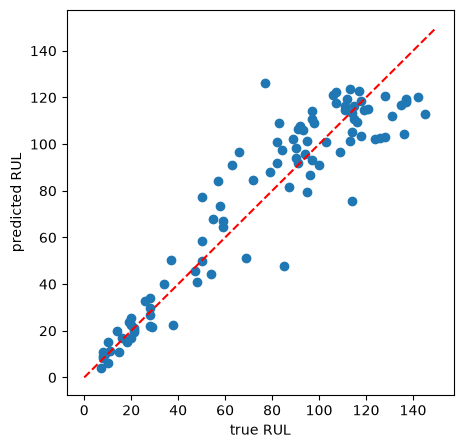

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

err = xgb_test - y_test   # positive = predicted too much life (late)
band = pd.cut(y_test, bins=[0, 25, 50, 75, 100, 150],
              labels=["0-25", "26-50", "51-75", "76-100", "101+"])

summary = (pd.DataFrame({"band": band, "err": err})
           .groupby("band", observed=True)["err"]
           .agg(n="size",
                rmse=lambda e: np.sqrt(np.mean(e ** 2)),
                bias="mean"))
print(summary.round(1))

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, xgb_test)
ax.plot([0, 150], [0, 150], "r--")
ax.set_xlabel("true RUL")
ax.set_ylabel("predicted RUL")
plt.show()